# Notebook EDA – Chatbot Edukatif IPA Kelas 5
Notebook ini berisi loading data, cleaning, EDA, visualisasi, dan baseline retrieval sederhana.

In [3]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "data" / "datasoal.csv"
DATA_PATH


WindowsPath('c:/Users/muham/Downloads/procesdata/submission/data/datasoal.csv')

In [4]:
def read_dataset(path):
    encodings = ("utf-8-sig", "utf-8", "latin1")
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as exc:
            last_error = exc
    raise last_error

def normalize_columns(df):
    df = df.copy()
    df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]
    for col in list(df.columns):
        if col.replace("_", " ") == "link sumber buku":
            df = df.rename(columns={col: "link_sumber_buku"})
    return df

def clean_text(value):
    if pd.isna(value):
        return ""
    text = str(value).lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[“”\"'`]", "", text)
    text = re.sub(r"[^0-9a-zA-ZÀ-ÿ\s\-\?\!\,\.\:\;\(\)]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def prepare_dataset(df):
    df = normalize_columns(df)
    for col in ["topik", "subtopik", "soal", "jawaban", "contoh", "konteks", "link_sumber_buku"]:
        if col not in df.columns:
            df[col] = ""
    if "no" not in df.columns:
        df["no"] = range(1, len(df) + 1)
    for col in ["topik", "subtopik", "soal", "jawaban", "contoh", "konteks"]:
        df[col] = df[col].astype(str).map(clean_text)
    df["soal_len"] = df["soal"].str.split().map(len)
    df["jawaban_len"] = df["jawaban"].str.split().map(len)
    df = df.drop_duplicates(subset=["soal", "jawaban"]).reset_index(drop=True)
    df["no"] = range(1, len(df) + 1)
    return df

df_raw = read_dataset(DATA_PATH)
df = prepare_dataset(df_raw)
df.head()


,no,topik,subtopik,soal,jawaban,contoh,konteks,link_sumber_buku,soal_len,jawaban_len
0,1,benda dan sifatnya,hubungan sifat bahan dan bahan penyusunnya,kenapa benda dibuat dari bahan yang berbeda-beda?,benda dibuat dari bahan yang berbeda-beda kare...,"buku dibuat dari kertas supaya bisa ditulis, s...",setiap bahan memiliki sifat yang berbeda seper...,https://www.omahbse.com/ktsp/file/sd-5_ipa_013/,7,35
1,2,benda dan sifatnya,hubungan sifat bahan dan bahan penyusunnya,apa alasan benda dibuat dari bahan yang berbed...,benda dibuat dari bahan yang berbeda-beda kare...,"buku dibuat dari kertas supaya bisa ditulis, s...",setiap bahan memiliki sifat yang berbeda seper...,https://www.omahbse.com/ktsp/file/sd-5_ipa_013/,8,35
2,3,benda dan sifatnya,hubungan sifat bahan dan bahan penyusunnya,mengapa benda dibuat dari bahan yang berbeda-b...,benda dibuat dari bahan yang berbeda-beda kare...,"buku dibuat dari kertas supaya bisa ditulis, s...",setiap bahan memiliki sifat yang berbeda seper...,https://www.omahbse.com/ktsp/file/sd-5_ipa_013/,7,35
3,4,benda dan sifatnya,hubungan sifat bahan dan bahan penyusunnya,mengapa tali harus kuat dan lentur?,tali harus kuat agar tidak mudah putus saat me...,"tali pramuka, tali jemuran, dan tali pancing d...",setiap bahan memiliki sifat yang berbeda seper...,https://www.omahbse.com/ktsp/file/sd-5_ipa_013/,6,25
4,5,benda dan sifatnya,hubungan sifat bahan dan bahan penyusunnya,apa alasan tali harus kuat dan lentur?,tali harus kuat agar tidak mudah putus saat me...,"tali pramuka, tali jemuran, dan tali pancing d...",setiap bahan memiliki sifat yang berbeda seper...,https://www.omahbse.com/ktsp/file/sd-5_ipa_013/,7,25


In [5]:
df.shape, df.columns.tolist()


((706, 10),
 ['no',
  'topik',
  'subtopik',
  'soal',
  'jawaban',
  'contoh',
  'konteks',
  'link_sumber_buku',
  'soal_len',
  'jawaban_len'])

In [6]:
df.isna().sum()


no                  0
topik               0
subtopik            0
soal                0
jawaban             0
contoh              0
konteks             0
link_sumber_buku    0
soal_len            0
jawaban_len         0
dtype: int64

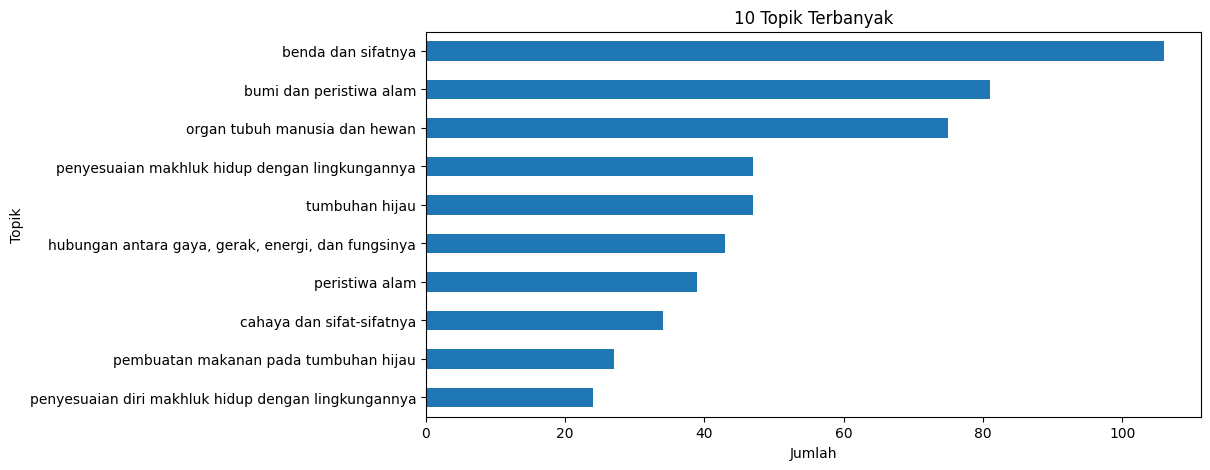

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
df["topik"].value_counts().head(10).sort_values().plot(kind="barh", ax=ax)
ax.set_title("10 Topik Terbanyak")
ax.set_xlabel("Jumlah")
ax.set_ylabel("Topik")
plt.show()


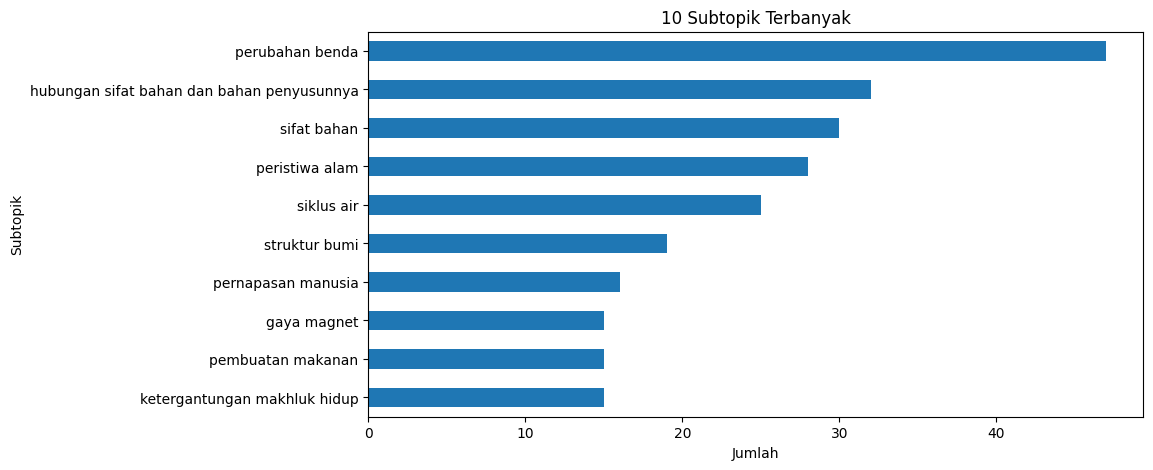

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
df["subtopik"].value_counts().head(10).sort_values().plot(kind="barh", ax=ax)
ax.set_title("10 Subtopik Terbanyak")
ax.set_xlabel("Jumlah")
ax.set_ylabel("Subtopik")
plt.show()


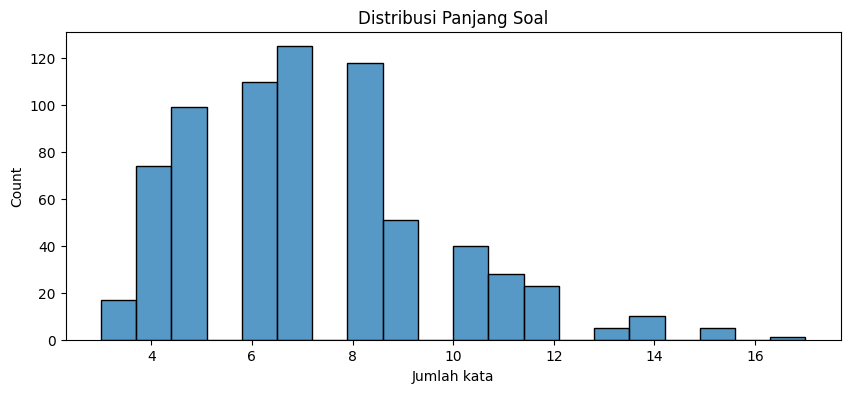

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["soal_len"], bins=20, ax=ax)
ax.set_title("Distribusi Panjang Soal")
ax.set_xlabel("Jumlah kata")
plt.show()


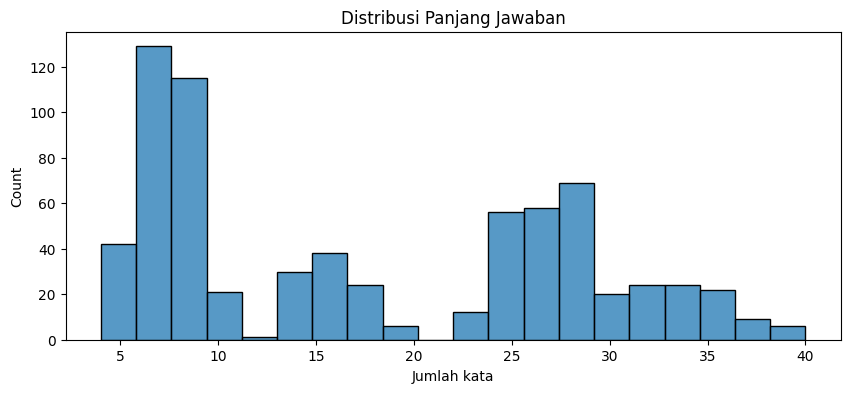

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["jawaban_len"], bins=20, ax=ax)
ax.set_title("Distribusi Panjang Jawaban")
ax.set_xlabel("Jumlah kata")
plt.show()


In [11]:
corpus = (df["soal"] + " " + df["jawaban"]).tolist()
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=6000)
matrix = vectorizer.fit_transform(corpus)

def retrieve_answer(query):
    q_vec = vectorizer.transform([clean_text(query)])
    scores = cosine_similarity(q_vec, matrix).flatten()
    idx = scores.argmax()
    return df.iloc[idx], scores[idx]

sample_query = "Apa fungsi akar pada tumbuhan?"
best_row, score = retrieve_answer(sample_query)
score, best_row[["topik", "subtopik", "soal", "jawaban"]]


(0.4783204019897947,
 topik                                          tumbuhan hijau
 subtopik                                      bagian tumbuhan
 soal                           apa fungsi akar pada tumbuhan?
 jawaban     akar berfungsi menyerap air dan zat hara dari ...
 Name: 273, dtype: object)

## Kesimpulan
Notebook ini bisa dipakai untuk EDA awal dan baseline retrieval sebelum integrasi ke chatbot.